# The Two-Site Hubbard Model

### Section 1.0 - Import Libraries

In [26]:
# Import model.py and utils.py

from model import * 
from utils import *

In [27]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from itertools import combinations

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from qiskit.quantum_info import Statevector

from qiskit.primitives import StatevectorEstimator

from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.circuit.library import efficient_su2

from qiskit.circuit import QuantumCircuit
from qiskit_nature.second_q.circuit.library import UCC, HartreeFock

from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.operators import FermionicOp

In [28]:
# Connect to IBM instance

your_api_key = "sEM8_FiU-KRrqRBhsuVTLRUbRhaDaxTrvKzjUdBiPTEI"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/283770ff49a2472b9b3ced6f9fb5e9f6:a3ef12e7-feb7-4ae0-8333-7dc44f53b938::"

QiskitRuntimeService.save_account(
     channel="ibm_quantum_platform",
     token=your_api_key,
     instance=your_crn,
     overwrite=True)

### Section 2.0 - Define Hubbard Model Problem

In [29]:
U = 4.0 # Set site energy
t = 1.0 # Set hopping energy
n_sites = 2 # Number of sites

Hubbard_model_n_elec = (1, 1) # Tuple defining the number of spin up electrons and the spin down electrons

n_e_up = Hubbard_model_n_elec[0] # Number of spin up electrons
n_e_down = Hubbard_model_n_elec[1] # Number of spin down electrons

In [30]:
aer_sim = True # 'True' if the user wants to use the Aer Simulator; 'False' if the user wants to run on hardware

In [31]:
def get_Hubbard_model(n_sites: int, n_electrons, site_potential: float, coupling_energy: float, periodic_bool: bool):
    """
    A function to define the Hubbard model geometry and energies

    Args:
    n_sites = the number of sites in the model.
    n_electrons = the number of up spin electrons and down spin electrons.
    site_potential = the potential energy associated with each site.
    coupling_energy = the interaction energy between electrons on different sites.
    periodic_bool = parameter to say whether periodic boundary conditions are enforced or not.

    Outputs:
    The definition of the Hubbard model of interest.
    """

    model = Hubbard1D(nsites=n_sites,
                      nelectrons=n_electrons,
                      U=site_potential,
                      t=coupling_energy,
                      periodic=periodic_bool)

    return model

### Section 3 - Construct Hamiltonian

In [32]:
def get_Hamiltonian():
    """
    A function to return the qubitised Hamiltonian of a given Hubbard model.

    Args:
    Hubbard_model = the defintiion of the Hubbard model.

    Outputs:
    The qubitised Hamiltonian corresponding to the Hubbard model of interest.
    """

    one_e_int, two_e_int = Hubbard_model.one_two_electron_integrals() # Calculate the one-electron and two-electron integrals
    
    # Create an object to encode the one-electron and two-electron integrals in Physicists' notation
    integrals = ElectronicIntegrals.from_raw_integrals(h1_a = one_e_int,
                                                       h1_b = one_e_int,
                                                       h2_aa = two_e_int,
                                                       h2_bb = two_e_int,
                                                       h2_ba = two_e_int,
                                                       auto_index_order=True)

    #H_fermi = ElectronicEnergy(integrals).second_q_op()

    H_fermi = FermionicOp({'+_0 -_1': -t,
                           '+_1 -_0': -t,
                           '+_2 -_3': -t,
                           '+_3 -_2': -t,
                           '+_0 -_0 +_2 -_2': U,
                           '+_1 -_1 +_3 -_3': U})

    # Note that the Jordan-Wigner map assumed H_fermi is defined on a spin-blocked basis, ie mode 0 = site 1, up spin and mode 1 = site 2, up spin
    qubit_mapper = JordanWignerMapper()

    H_qubit = qubit_mapper.map(H_fermi)

    return H_qubit

### Section 4.0 - Obtain the Hubbard Model, Hamiltonian and Ansatz

In [33]:
Hubbard_model = get_Hubbard_model(n_sites, Hubbard_model_n_elec, U, t, False) # Obtain the model

H = get_Hamiltonian() # Calcaulate the qubitised Hamiltonian

q_mapper = JordanWignerMapper()

# Generate the initial Hartree-Fock state
initial_state = HartreeFock(num_spatial_orbitals=n_sites,
                            num_particles=(n_e_up, n_e_down),
                            qubit_mapper=q_mapper)

# Generate the ansatz
ansatz = UCC(num_spatial_orbitals=n_sites,
             num_particles=(n_e_up, n_e_down),
             excitations='sd',
             qubit_mapper=q_mapper,
             initial_state=initial_state,
             generalized=True,
             reps=1)

n_params = ansatz.num_parameters # Determine the number of parameters in the ansatz

params_0 = np.zeros(n_params) # Initialise the ansatz parameters

The number of two-qubit gates is 52.


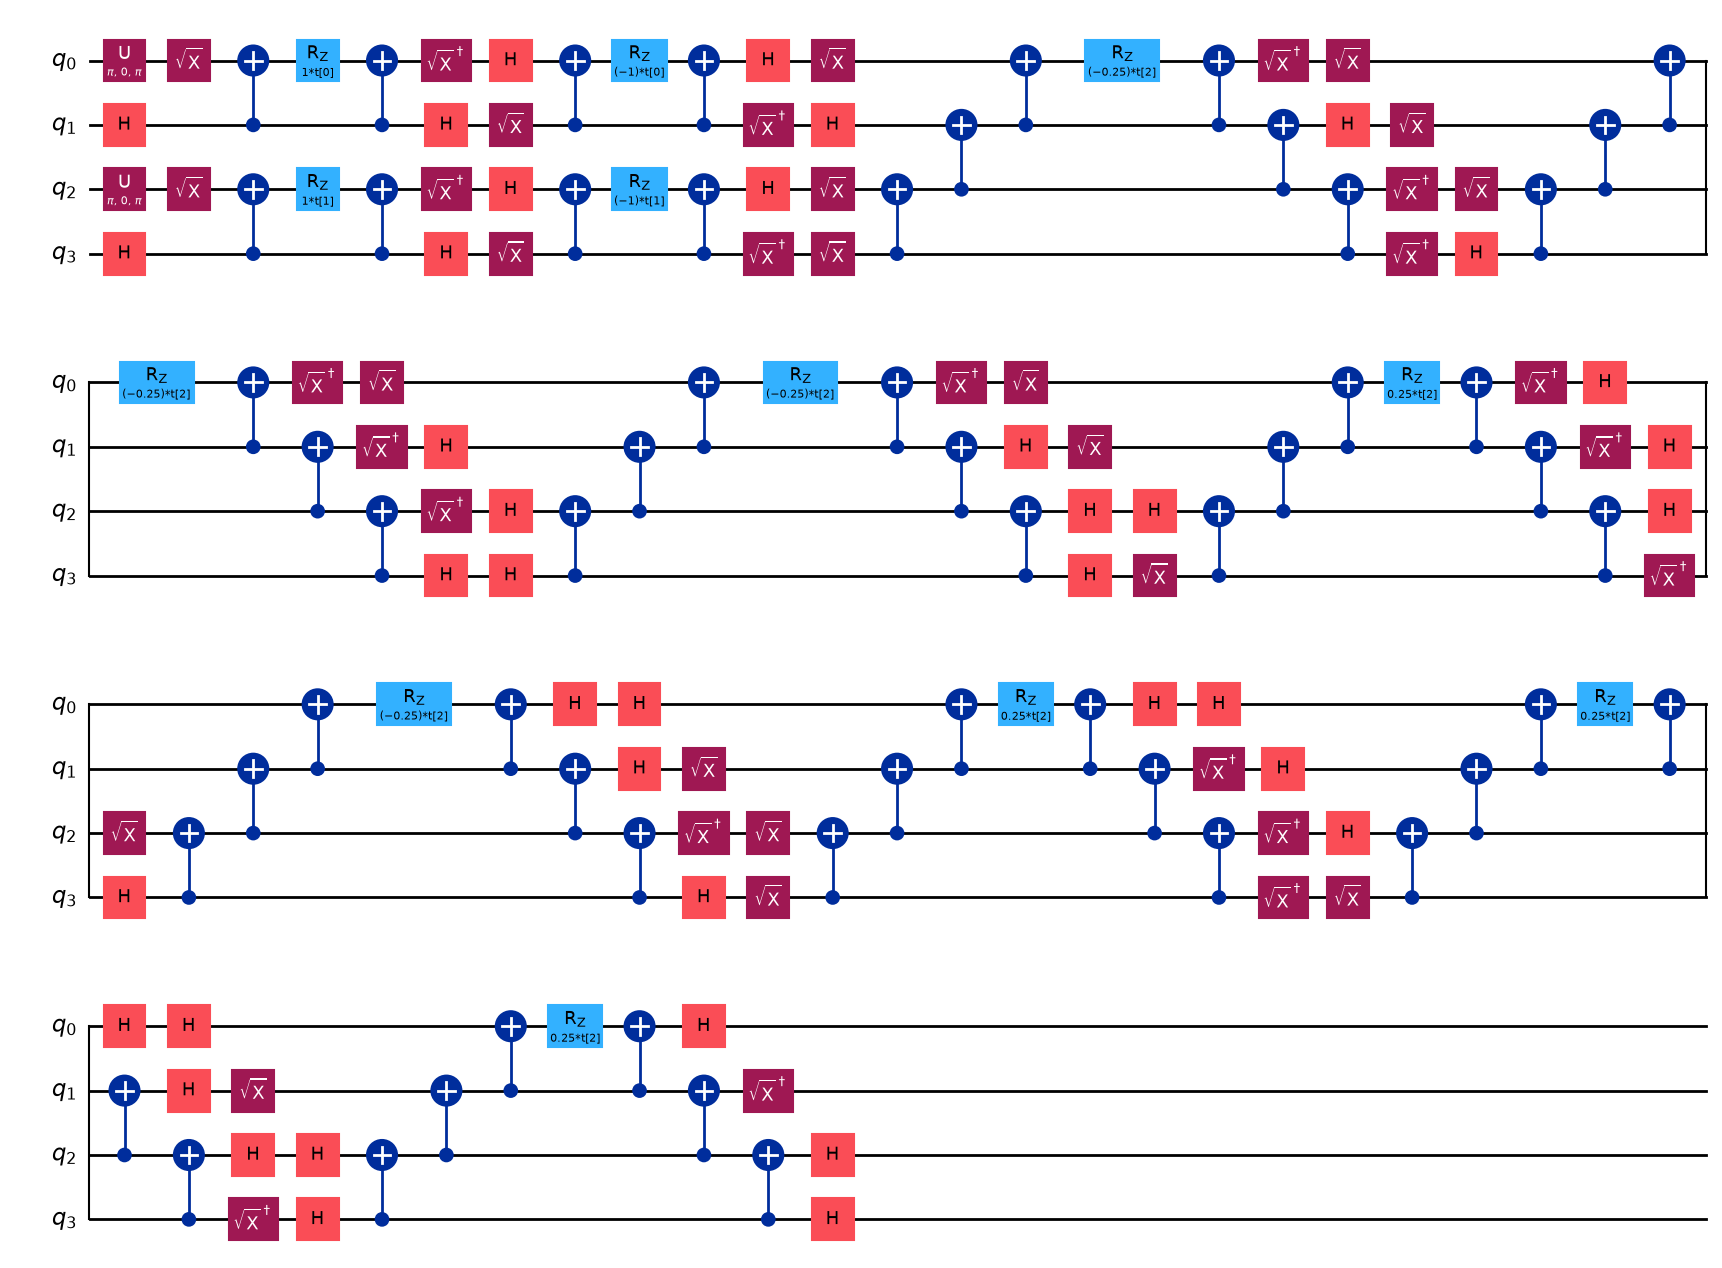

In [34]:
n_2_qubt_gates = ansatz.decompose().decompose().depth(lambda x: x.operation.num_qubits == 2)
print(f'The number of two-qubit gates is {n_2_qubt_gates}.') # Calcualte the number of 2-qubit operations

ansatz.decompose().decompose().draw('mpl', style='iqp') # Draw the quantum circuit

#### Section 4.3 - Select the IBM Hardware to Run Circuit On

In [35]:
# Select the IMB backend with the fewest number of jobs in the queue
service = QiskitRuntimeService() # Point to the IBM backend services
backend = service.least_busy(operational=True, simulator=False) # Select the least busy QPU

# Select the Aer Simulator if the aer_sim bool is true
if aer_sim == True:
    backend = AerSimulator.from_backend(backend, noise_model=None)

In [36]:
print(f'The selected QPU is: {backend}') # Return the selected backend QPU

The selected QPU is: AerSimulator('aer_simulator_from(ibm_marrakesh)')


### Section 5.0 - Define the Cost Function

In [37]:
def cost_function(params, ansatz, Hamiltonian, estimator, iteration_history):
    """
    A function which defines the cost function for our VQE algorithm.

    Args:
    params = the parameters which will be optimised by the VQE.
    ansatz = the ansatz for the VQE.
    Hamiltonian = the Hamiltonian which defines the Hubbard model.
    estimator = initial estimator for the optimised energy of the Hubbard model.
    iteration_history = a dictionary to store results as aa function of iteration number.

    Returns:
    An estimate of the energy of the Hubbard model.
    """

    pub = (ansatz, [Hamiltonian], [params]) # Define the Primitive Unit Block (PUB) for the problem which defines the computation work for the QPU
    result = estimator.run(pubs=[pub]).result() # Submits the PUB to the Estimator primitive for calculation
    energy = result[0].data.evs[0] # Obtain the ground state energy

    iteration_history['Iteration Number'] += 1 # Increase the iteration count by one
    iteration_history['Optimised Parameters'] = params # Update the optimised parameters
    iteration_history['Energies'].append(energy) # Append the new ground state energy

    print(f'Iterations Completed: {iteration_history['Iteration Number']}, Current Cost: {energy}.')

    return energy

### Section 6.0 - Run the State Vector VQE Calculation

In [38]:
state_vec_est = StatevectorEstimator()

# Initialise the iteration history dictionary for state vector simulations
iteration_his_state_vec_sim = {'Iteration Number': 0,
                               'Optimised Parameters': None,
                               'Energies': []}

optimised_result = minimize(cost_function, # Parse the cost function
                            params_0, # Parse the initial parameters
                            args=(ansatz, H, state_vec_est, iteration_his_state_vec_sim), # Parse the ansatz, ISA Hamiltonian, estimator and dictionary
                            method="COBYLA", # The optimisation method
                            options={"maxiter": 300}) # The maximum number of iterations

Iterations Completed: 1, Current Cost: 4.0.
Iterations Completed: 2, Current Cost: 2.077003753731397.
Iterations Completed: 3, Current Cost: 4.16495123278775.
Iterations Completed: 4, Current Cost: 2.424149224573889.
Iterations Completed: 5, Current Cost: 0.4817286577732576.
Iterations Completed: 6, Current Cost: 0.09447190474615941.
Iterations Completed: 7, Current Cost: 0.5541376509171196.
Iterations Completed: 8, Current Cost: 0.8076236301255437.
Iterations Completed: 9, Current Cost: 0.5865679386463682.
Iterations Completed: 10, Current Cost: 1.820585549057552.
Iterations Completed: 11, Current Cost: -0.06118735250718543.
Iterations Completed: 12, Current Cost: 0.29013771724075604.
Iterations Completed: 13, Current Cost: -0.11074761772537045.
Iterations Completed: 14, Current Cost: -0.26993733779402396.
Iterations Completed: 15, Current Cost: -0.35731918549883634.
Iterations Completed: 16, Current Cost: -0.25941509566006227.


/opt/anaconda3/envs/qiskit/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/anaconda3/envs/qiskit/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Iterations Completed: 17, Current Cost: -0.368576869323589.
Iterations Completed: 18, Current Cost: -0.44963730378393696.
Iterations Completed: 19, Current Cost: -0.4893249783041346.
Iterations Completed: 20, Current Cost: -0.4906414407364945.
Iterations Completed: 21, Current Cost: -0.48131598776915296.
Iterations Completed: 22, Current Cost: -0.4640793342961944.
Iterations Completed: 23, Current Cost: -0.47279411648162695.
Iterations Completed: 24, Current Cost: -0.48551336648817367.
Iterations Completed: 25, Current Cost: -0.4973641668008896.
Iterations Completed: 26, Current Cost: -0.4964200845461394.
Iterations Completed: 27, Current Cost: -0.497508297841045.
Iterations Completed: 28, Current Cost: -0.49877066503196954.
Iterations Completed: 29, Current Cost: -0.49915075051890156.
Iterations Completed: 30, Current Cost: -0.4990092438133634.
Iterations Completed: 31, Current Cost: -0.4983744015635859.
Iterations Completed: 32, Current Cost: -0.4999264072027235.
Iterations Completed

### Section 7.0 - Construct the Quantum Circuit and Run the VQE Algorithm

#### Section 7.1 - Transpile the Quantum Circuit

In [39]:
target = backend.target # Obtain QPU constraints for optimal circuit compilation

pm = generate_preset_pass_manager(target=target, optimization_level=3) # Generate a pass manager for code transpilation

ansatz_isa = pm.run(ansatz) # Transpile the code to an Instructuon Set Architecture (ISA) optimised for a QPU

H_isa = H.apply_layout(layout=ansatz_isa.layout) # Map the Hamiltonian to the exact structure as the ansatz ISA

The number of two-qubit gates is 45.


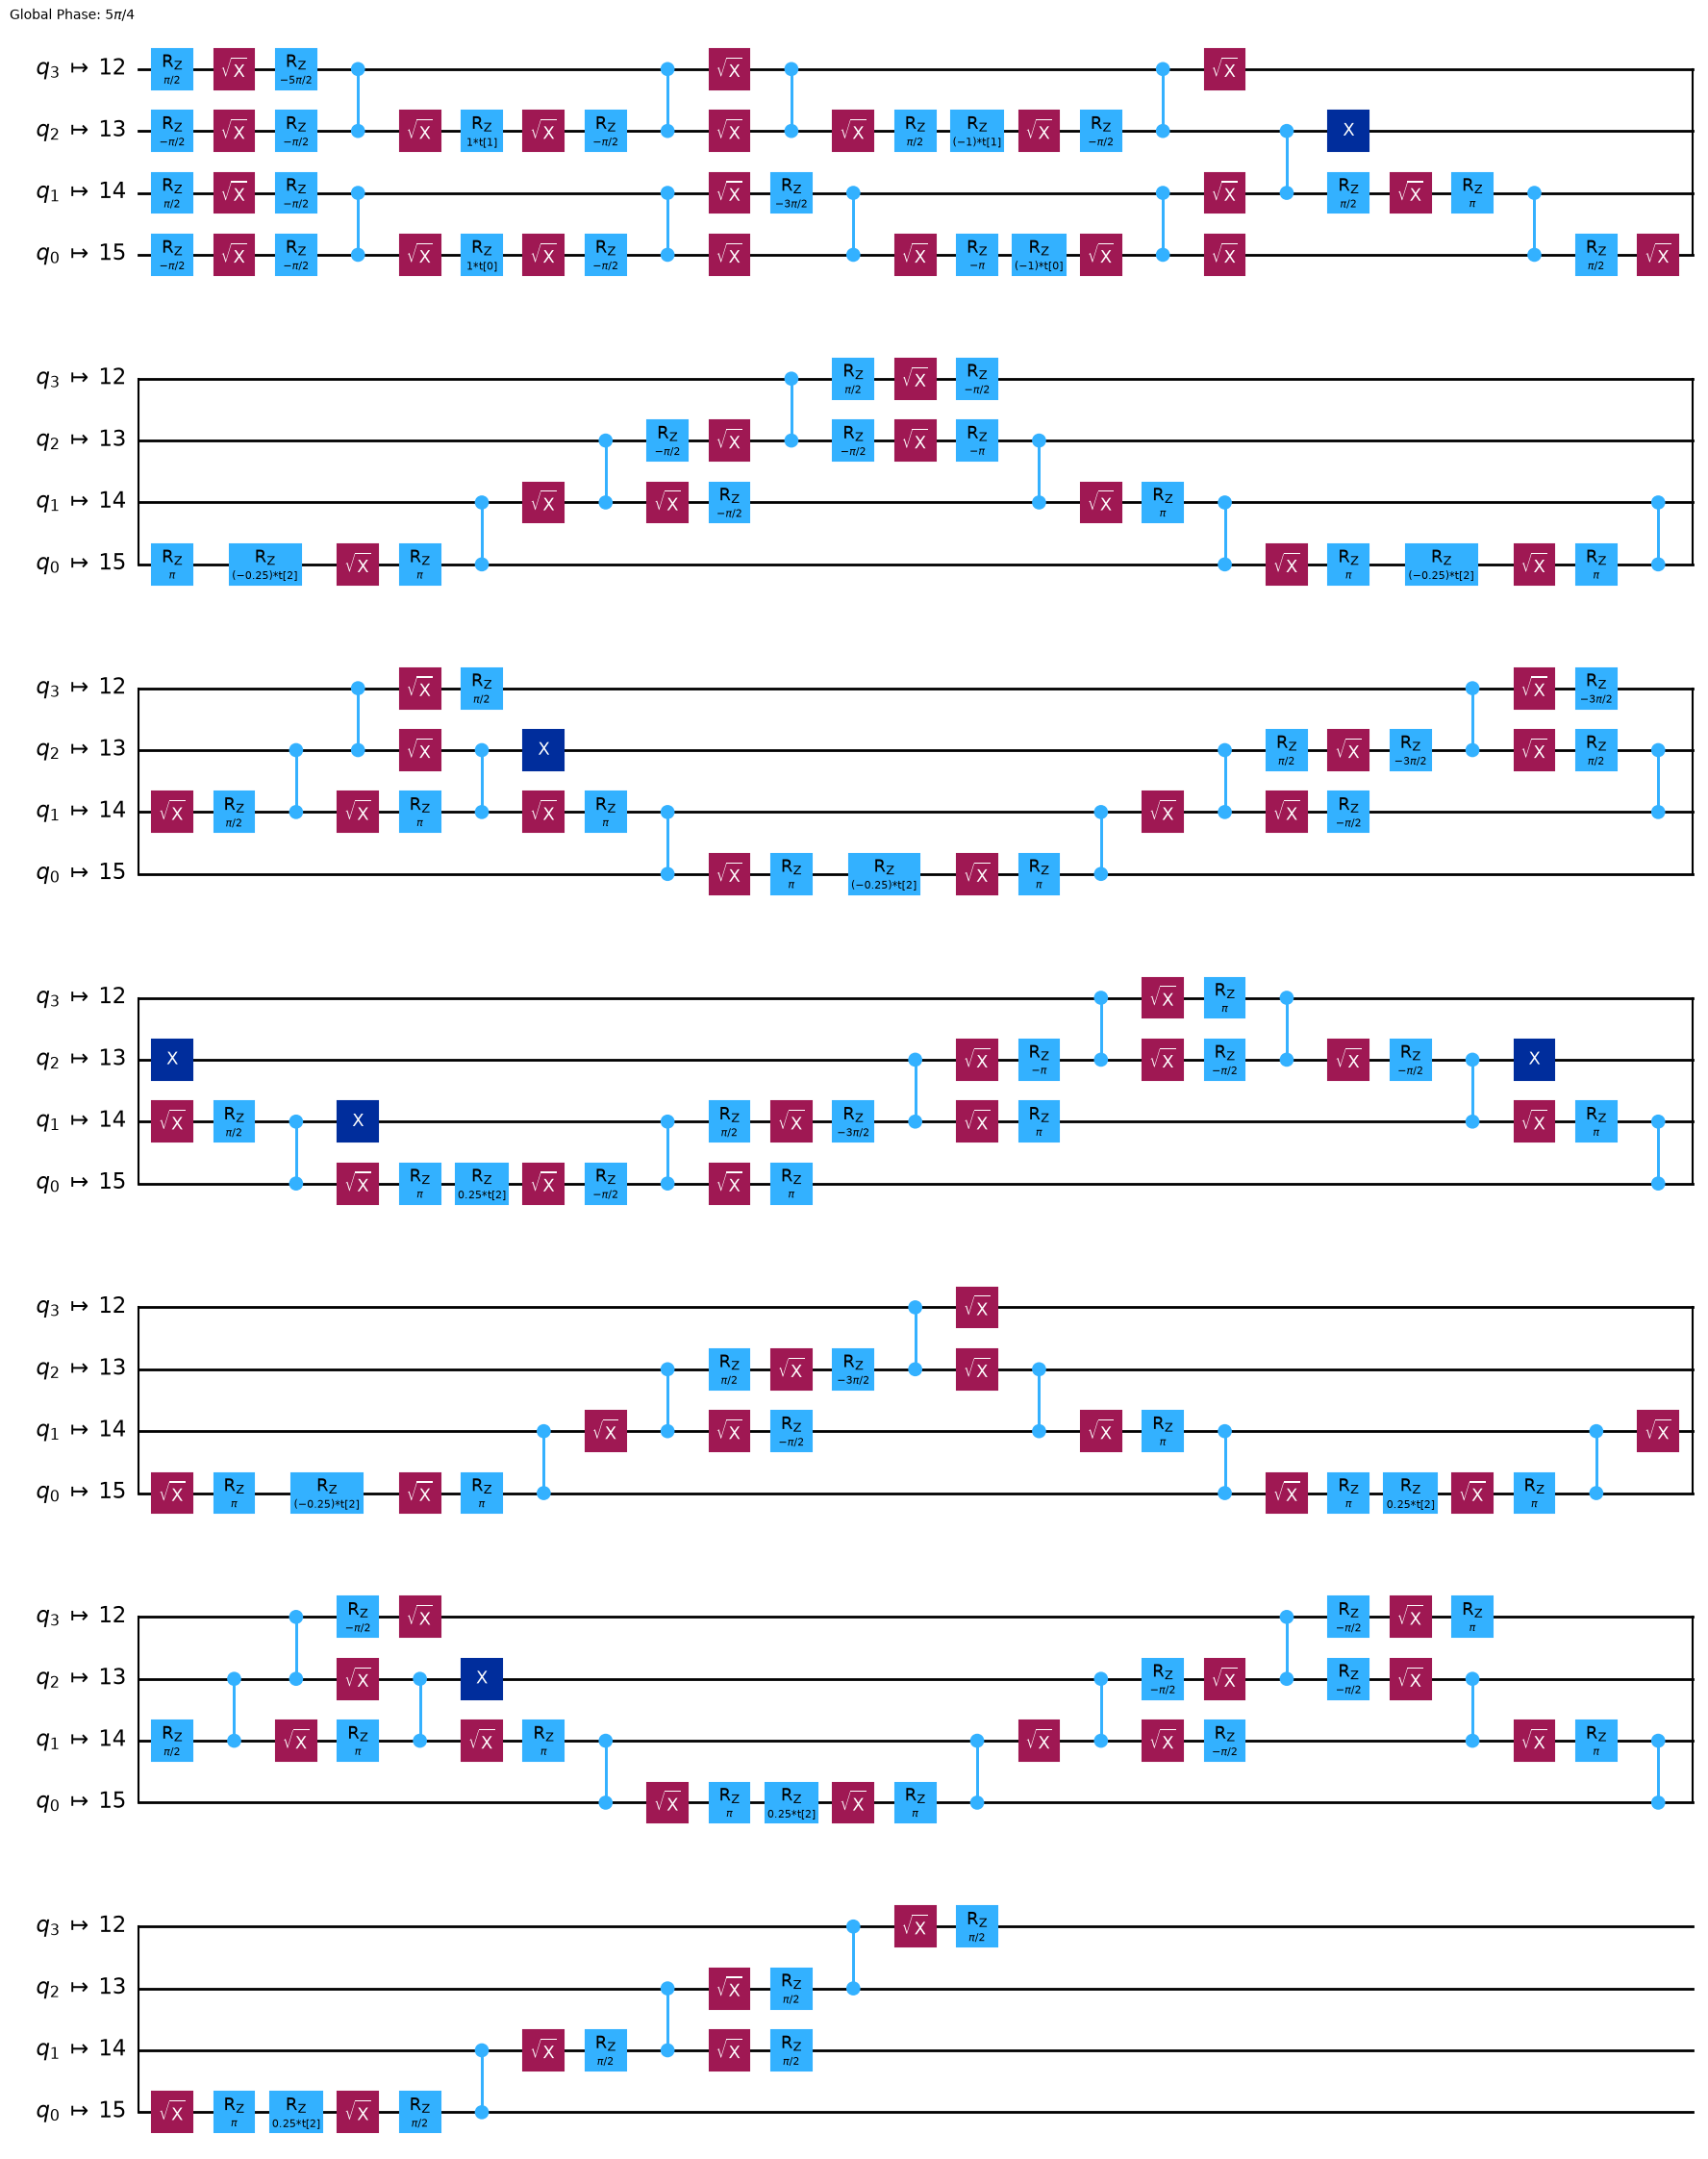

In [40]:
# Calcualte the number of 2-qubit operations post transpilation
n_2_qubt_gates_post_transpilation = ansatz_isa.decompose().decompose().depth(lambda x: x.operation.num_qubits == 2)
print(f'The number of two-qubit gates is {n_2_qubt_gates_post_transpilation}.')

ansatz_isa.draw('mpl', style='iqp') # Draw the quantum circuit post transpilation

#### Section 7.2 - Run the VQE Algorithm

In [41]:
# Initialise the iteration history dictionary for VQE QPU simulations
iteration_his_qpu_sim = {'Iteration Number': 0,
                         'Optimised Parameters': None,
                         'Energies': []}

with Session(backend=backend) as session:
    estimator = Estimator(mode=session) # Call the estimator with the selected QPU
    estimator.options.default_shots = 5000 # Set the total number of shots per circuit configuration

    optimised_result = minimize(cost_function, # Parse the cost function
                                params_0, # Parse the initial parameters
                                args=(ansatz_isa, H_isa, estimator, iteration_his_qpu_sim), # Parse the ansatz, ISA Hamiltonian, estimator and dictionary
                                method="cobyla", # The optimisation method
                                options={"maxiter": 150}) # The maximum number of iterations

Iterations Completed: 1, Current Cost: 3.9972.
Iterations Completed: 2, Current Cost: 2.0502000000000002.
Iterations Completed: 3, Current Cost: 4.124600000000001.
Iterations Completed: 4, Current Cost: 2.3956.
Iterations Completed: 5, Current Cost: 0.43820000000000014.
Iterations Completed: 6, Current Cost: 0.7966000000000001.
Iterations Completed: 7, Current Cost: -0.2988000000000001.
Iterations Completed: 8, Current Cost: 0.5883999999999998.
Iterations Completed: 9, Current Cost: -0.40800000000000014.
Iterations Completed: 10, Current Cost: -0.238.
Iterations Completed: 11, Current Cost: -0.35579999999999984.
Iterations Completed: 12, Current Cost: -0.5047999999999999.
Iterations Completed: 13, Current Cost: -0.5057999999999999.
Iterations Completed: 14, Current Cost: -0.40340000000000026.
Iterations Completed: 15, Current Cost: -0.4712000000000002.
Iterations Completed: 16, Current Cost: -0.4570000000000001.
Iterations Completed: 17, Current Cost: -0.49619999999999986.
Iterations C

### Section 8.0 - Plot the Results

In [42]:
# Results from first quantum run (no initial state in UCC ansatz)

it_his_import = {'Iteration Number': 32,
 'Optimised Parameters': np.array([1.00221314, 0.00383399, 0.00245787]),
 'Energies': [np.float64(0.1839976041856426),
  np.float64(0.15451587242885922),
  np.float64(0.17219485924253675),
  np.float64(0.27159841583935174),
  np.float64(0.21705219668471754),
  np.float64(0.19923690774961433),
  np.float64(0.20204826647773688),
  np.float64(0.19238971164593432),
  np.float64(0.17583931515338946),
  np.float64(0.19954557404688278),
  np.float64(0.18604030518709647),
  np.float64(0.16619994656507586),
  np.float64(0.16872338449330082),
  np.float64(0.17751128443357023),
  np.float64(0.18485329318990662),
  np.float64(0.19320229450059723),
  np.float64(0.18545593201612365),
  np.float64(0.1450160231847003),
  np.float64(0.14541132871966067),
  np.float64(0.19048885985828612),
  np.float64(0.18220908208116549),
  np.float64(0.14836093450680465),
  np.float64(0.19742450027181047),
  np.float64(0.20052638613838136),
  np.float64(0.27659017494466365),
  np.float64(0.20981237616803017),
  np.float64(0.20345194367634412),
  np.float64(0.2243427978630037),
  np.float64(0.19596612731161323),
  np.float64(0.15817538623956628),
  np.float64(0.18996120081776457),
  np.float64(0.21336268154258153)]}

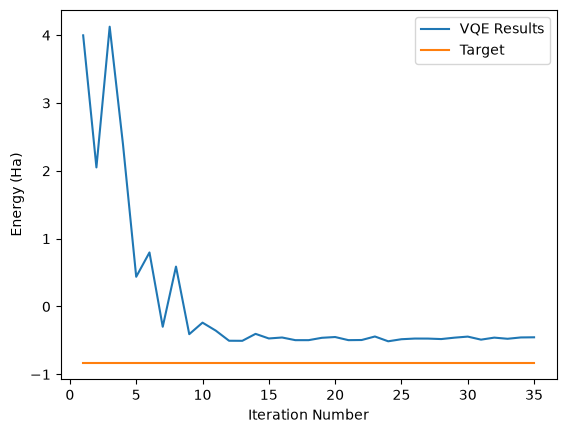

In [43]:
# Plot energy against iteration numnber
plt.plot(range(1, iteration_his_qpu_sim['Iteration Number'] + 1), iteration_his_qpu_sim['Energies'], label='VQE Results')

# Plot the target energy
plt.plot(range(1, iteration_his_qpu_sim['Iteration Number'] + 1), np.ones(iteration_his_qpu_sim['Iteration Number']) * -0.8284271247, label='Target')

plt.xlabel('Iteration Number') # Label the x-axis
plt.ylabel('Energy (Ha)') # Label the y-axis

plt.legend() # Add a legend to the plot

plt.show()

### Section 9 - Generate Moments

#### Section 9.1 - Generate the (E - H) Operator and the Optimised Ground State

In [44]:
H_size, _ = np.shape(H) # Get the size of the square Hamiltonian

E_0_VQE = iteration_his_qpu_sim['Energies'][iteration_his_qpu_sim['Iteration Number'] - 1] # Obtain the converged ground state energy

# Obtain a square matrix of size H_size with the converged ground state energy along the diagonal
energy_mat = np.identity(H_size) * E_0_VQE

energy_moment_operator = SparsePauliOp.from_operator(Operator(energy_mat)) - H # Calcualte the moment operator
energy_moment_operator = energy_moment_operator

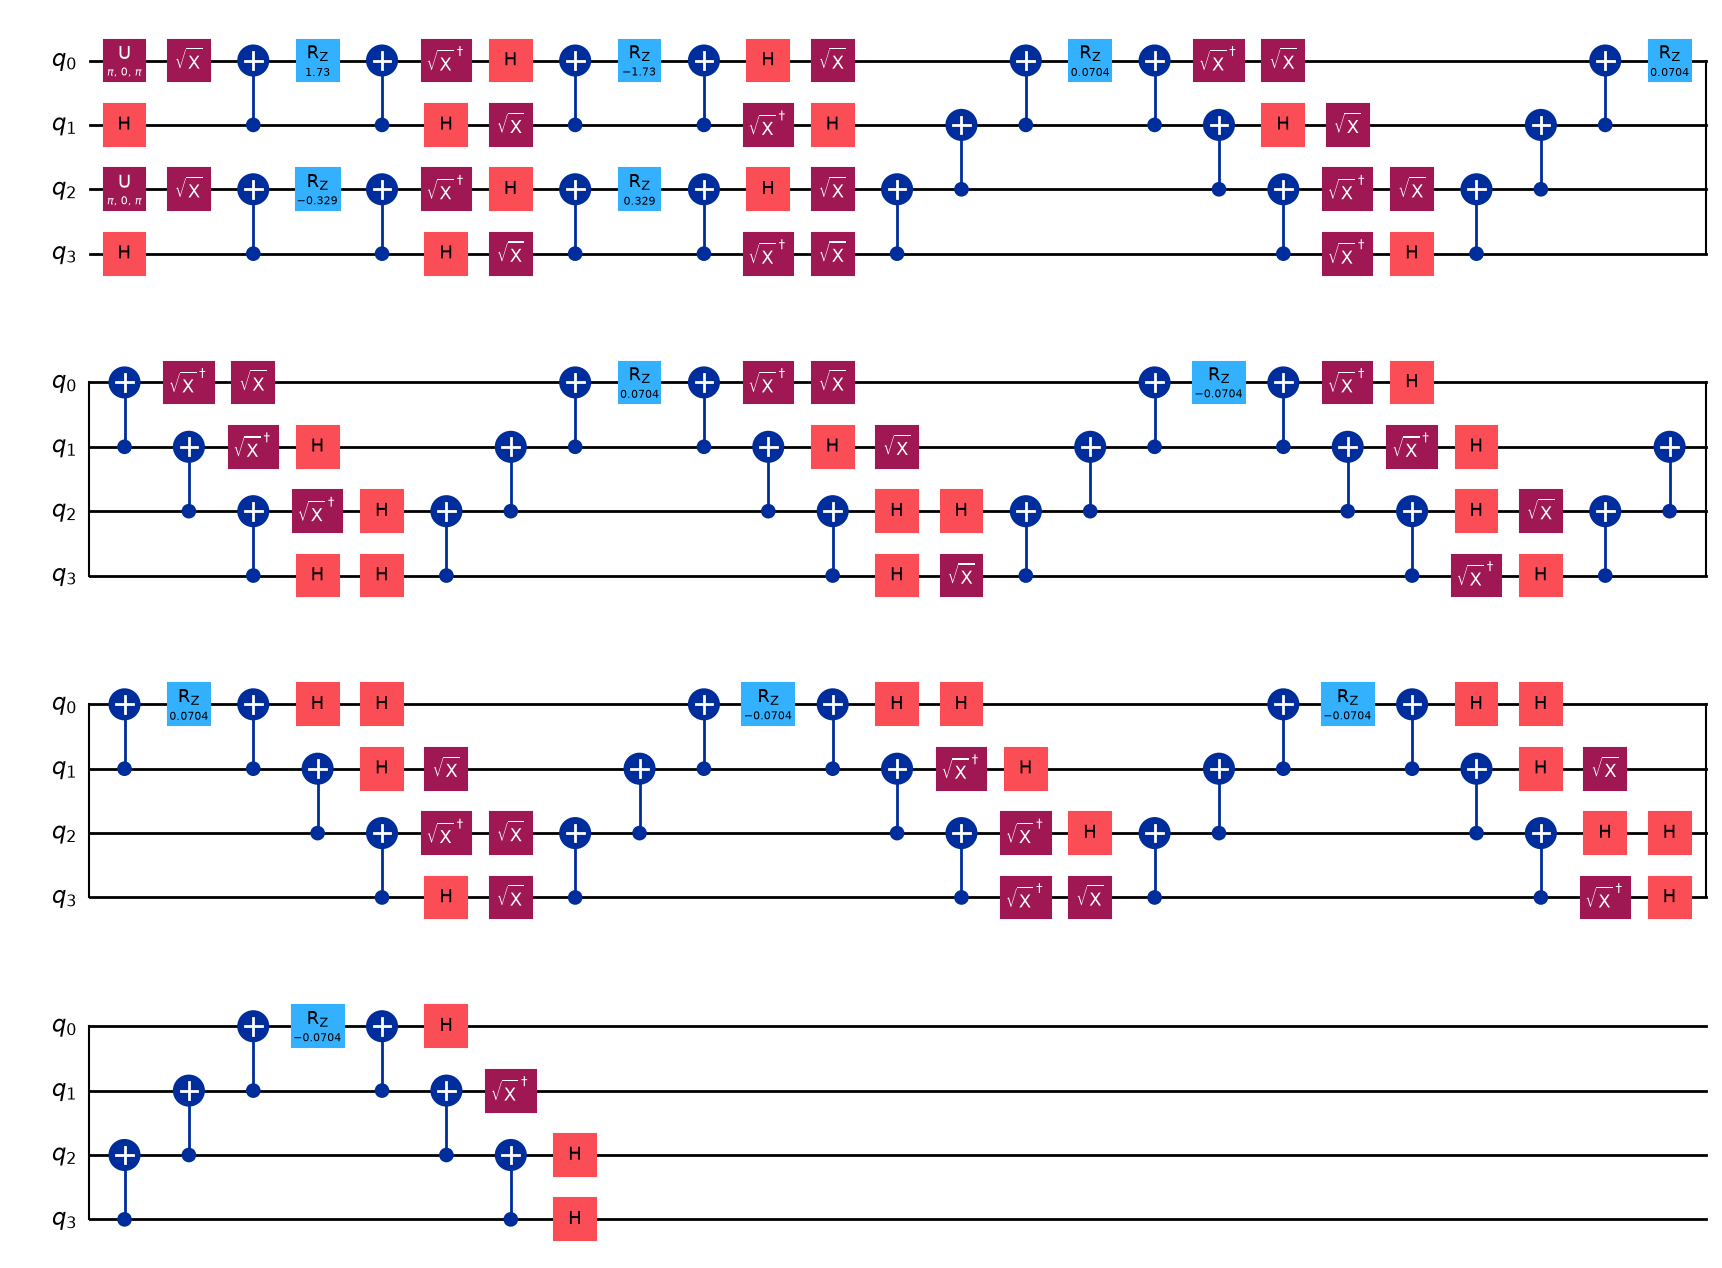

In [45]:
ground_state_circuit = ansatz.assign_parameters(np.array(iteration_his_qpu_sim['Optimised Parameters'])) # Obtain the ground state circuit
ground_state_circuit.decompose().decompose().draw('mpl', style='iqp') # Draw the optimised circuit

#### Section 9.3 - Define Creation and Annihilation Operators

In [46]:
def c_plus(site: float):
    """
    A function to encode the Fermionic creation operator.

    Args:
    site = the site where an electron is being added to.

    Output:
    The creation operator in the qubit representation.
    """
    c_plus_op = FermionicOp({f'+_{site}': 1}, num_spin_orbitals=4)

    return q_mapper.map(c_plus_op)

In [47]:
def c_minus(site: float):
    """
    A function to encode the Fermionic annihilation operator.

    Args:
    site = the site where an electron is being removed from.

    Output:
    The annihilation operator in the qubit representation.
    """
    c_minus_op = FermionicOp({f'-_{site}': 1}, num_spin_orbitals=4)

    return q_mapper.map(c_minus_op)

#### Section 9.4 - Transpile the Optimised Circuit

In [48]:
target_moments = backend.target # Obtain QPU constraints for optimal circuit compilation

pm = generate_preset_pass_manager(target=target_moments, optimization_level=3) # Generate a pass manager for code transpilation

ground_state_circuit_isa = pm.run(ground_state_circuit) # Transpile the ground state to an Instructuon Set Architecture (ISA) optimised for a QPU

The number of two-qubit gates is 43.


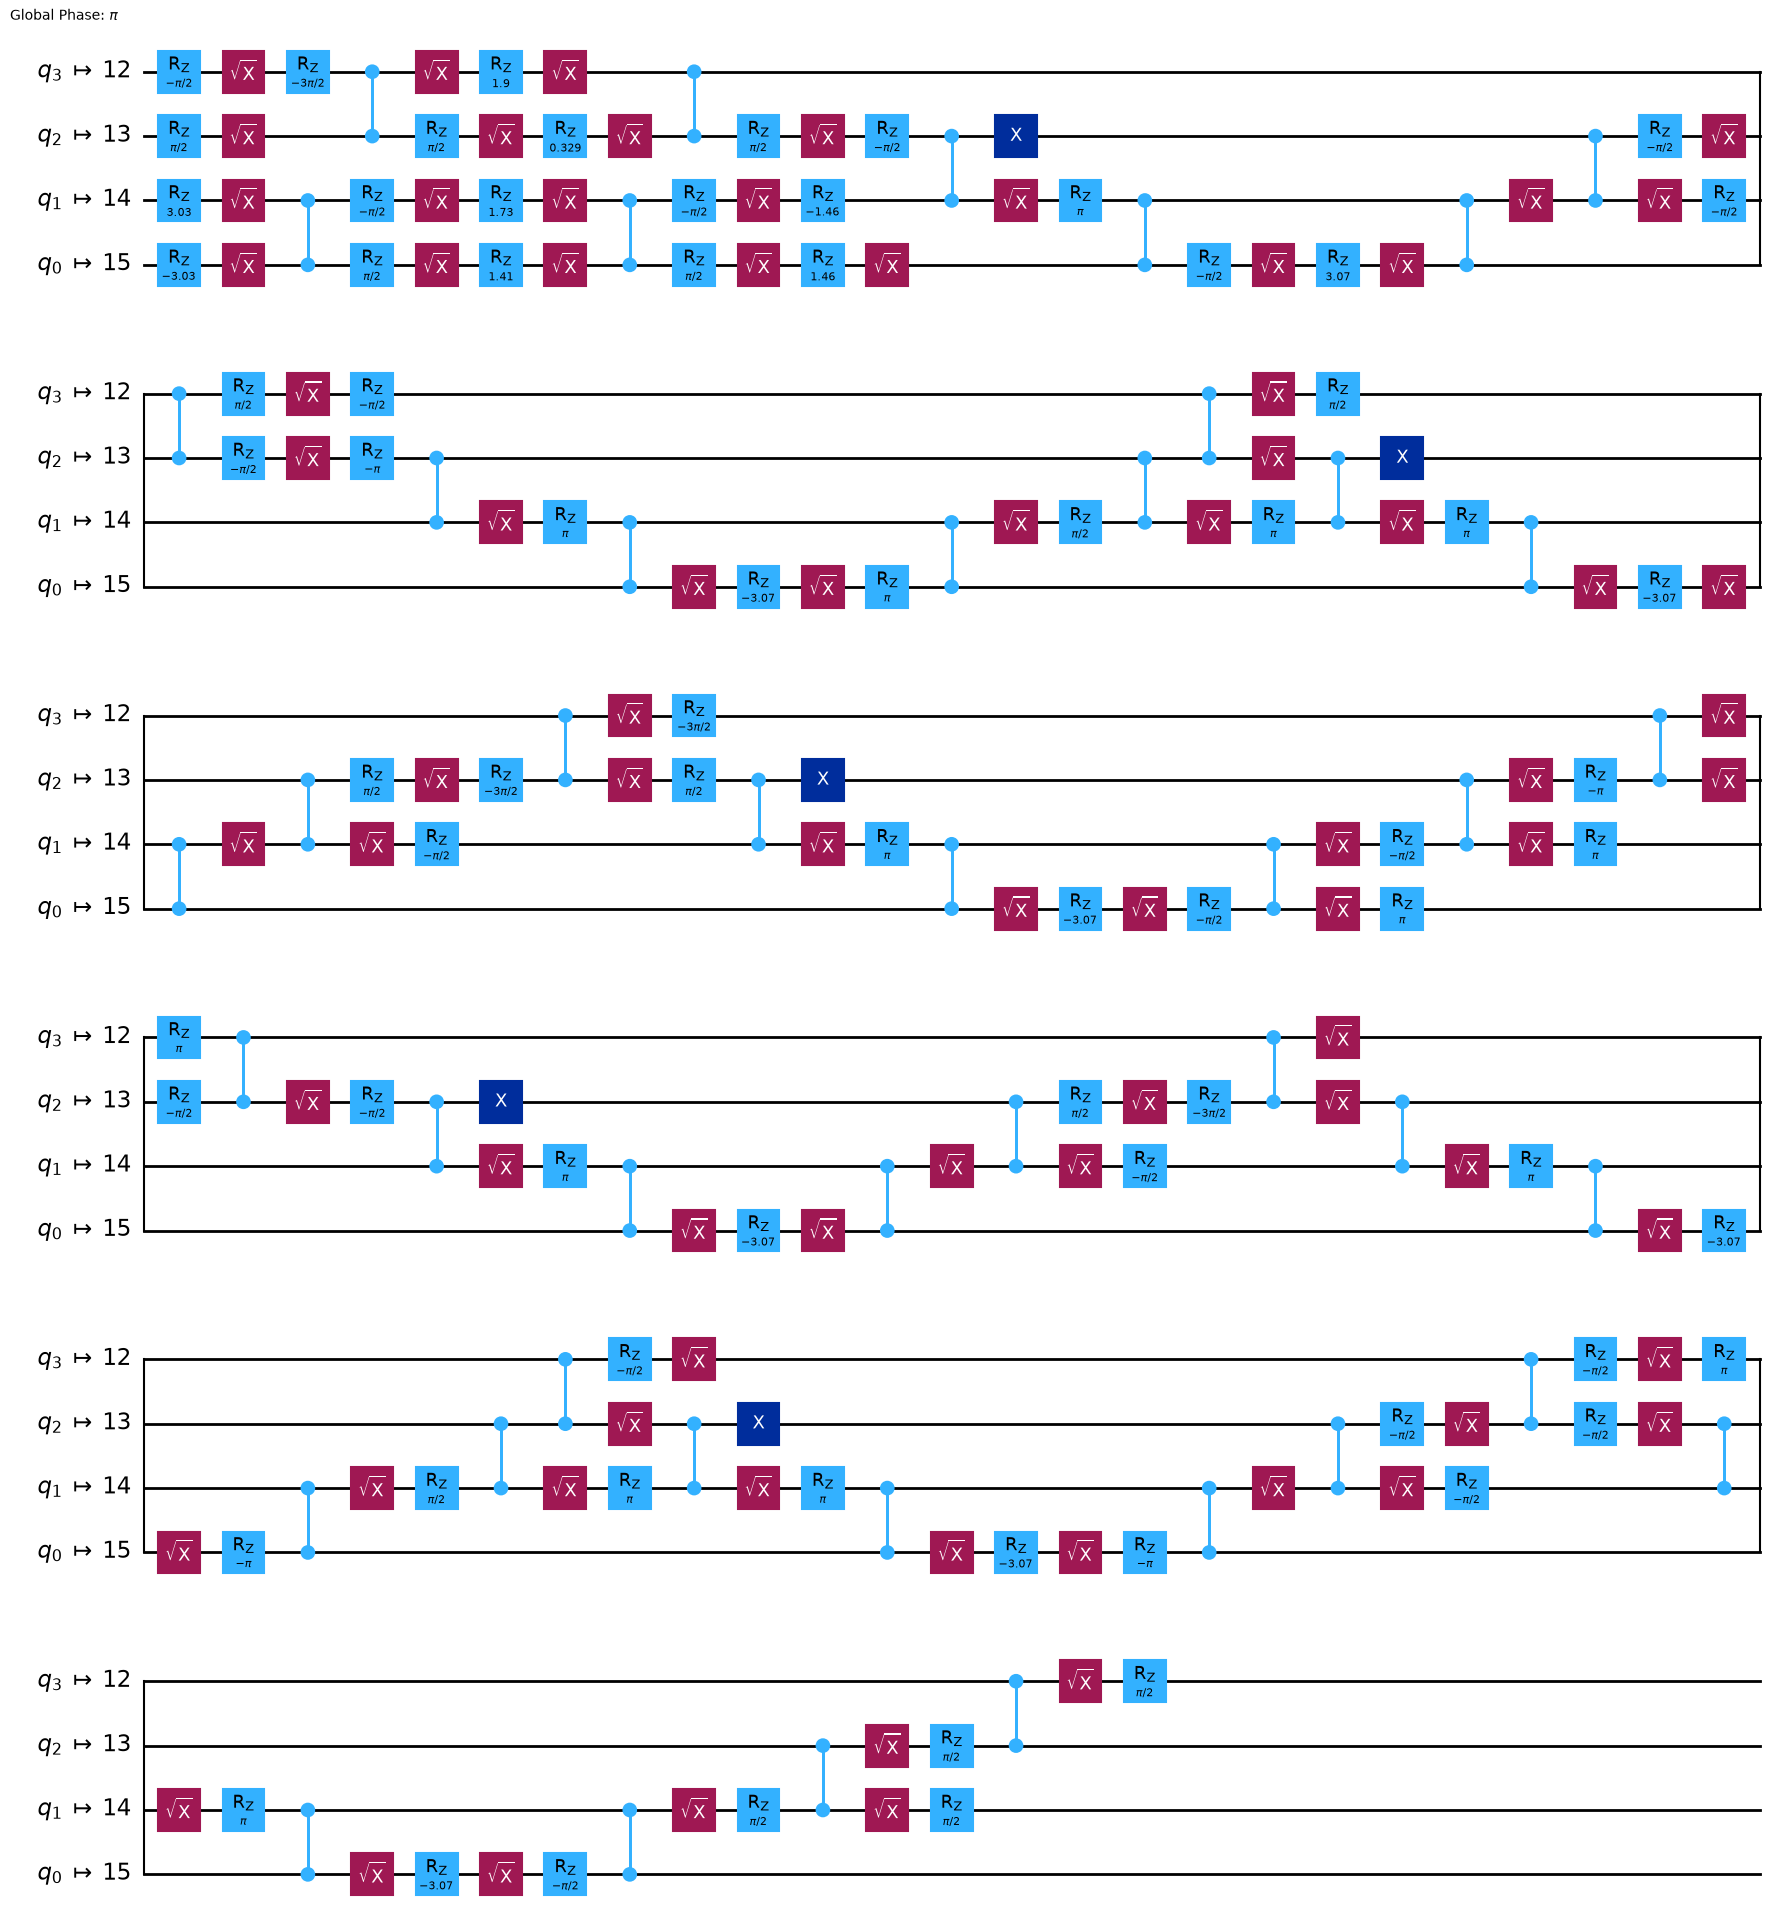

In [49]:
# Calcualte the number of 2-qubit operations post transpilation
n_2_qubt_gates_post_transpilation = ground_state_circuit_isa.decompose().decompose().depth(lambda x: x.operation.num_qubits == 2)
print(f'The number of two-qubit gates is {n_2_qubt_gates_post_transpilation}.')

ground_state_circuit_isa.draw('mpl', style='iqp') # Draw the quantum circuit post transpilation

#### Section 9.4 - Calcualte Moments up to the nth Order

In [50]:
max_moment_order = 3

moments_matrix = np.zeros((max_moment_order, n_sites, n_sites), dtype='complex')

estimator_moments = Estimator(mode=backend)

for order in range(max_moment_order):
    for n in range(n_sites):
        for m in range(n_sites):
            moment_operator = (c_plus(n) @ energy_moment_operator @ c_minus(m))

            exp_val_real = 0
            exp_val_im = 0

            for index in range(len(moment_operator)):

                # Map the moment operator to the exact structure as the circuit ISA
                P_string_moment_operator_isa = moment_operator[index].apply_layout(layout=ground_state_circuit_isa.layout)

                if P_string_moment_operator_isa.coeffs.real != 0:
                    job = estimator_moments.run([(ground_state_circuit_isa, P_string_moment_operator_isa)])

                    result = job.result()
                
                    exp_val_real += result[0].data.evs

                elif P_string_moment_operator_isa.coeffs.imag != 0:
                    job = estimator_moments.run([(ground_state_circuit_isa, P_string_moment_operator_isa * (-1j))])
                    
                    result = job.result()
                    
                    exp_val_im += result[0].data.evs

                else:
                    print(f'Index {index} of the (n, m) = ({n}, {m}) site case has both real and imaginary parts.')

            moments_matrix[order, n, m] = exp_val_real + (exp_val_im * 1j)

In [51]:
moments_matrix

array([[[ 7.34521484e-03+0.00683594j, -1.52199707e-02-0.03698193j],
        [ 7.32421875e-07+0.00187598j,  6.91162109e-02-0.00463867j]],

       [[ 3.63769531e-05-0.00158691j, -1.25419922e-02+0.01310229j],
        [-1.90236816e-02+0.00546436j,  7.10097656e-02-0.00183105j]],

       [[ 1.56411133e-02-0.00183105j,  1.45107422e-02+0.00011548j],
        [-2.73510742e-03-0.0171228j ,  6.83979492e-02-0.00054932j]]])